<a href="https://colab.research.google.com/github/Adukani26/Data-Wrangling/blob/practical-exercise-2/Airplane_Crashes_Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import pandas as pd


In [25]:
df = pd.read_csv("Airplane_Crashes_and_Fatalities_Since_1908.csv")
df.head()


,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
2,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
3,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
4,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...


In [26]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 5268
Number of columns: 13


In [27]:
df.tail(75)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,05/20/2009,06:30,"Near Madiun, Indonesia",Military - Indonesian Air Force,NaN,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,1982,112.0,98.0,2.0,"While on approach, the military transport cras..."
5264,05/26/2009,NaN,"Near Isiro, DemocratiRepubliCongo",Service Air,NaN,Goma - Isiro,Antonov An-26,9Q-CSA,5005,4.0,4.0,NaN,The cargo plane crashed while on approach to I...
5265,06/01/2009,00:15,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,447,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,660,228.0,228.0,0.0,The Airbus went missing over the AtlantiOcean ...
5266,06/07/2009,08:30,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,NaN,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,424,1.0,1.0,0.0,The air ambulance crashed into hills while att...


Question 4

a. Time - Leave as missing; Inputing a fake time is misleading since there's no average time

b.Location - Drop the rows; Location matters for the fatality_locations analysis later thus it can't be averaged.

c.Operator - fill with "Unknown"; this preserves the row for other analysis without inventing a real operator.

d.Route - Drop the column if more than 50% is missing else fill with "Unknown"; A high proportion of missing values makes the column unreliable and not worth retaining.

e.Type - Fill with "Unkown" or drop the rows; Missing values are few and do not materially affect the analysis

f.Registration - fill with "Unknown" This is an identifier field with no analytical or numerical significance.

g.cn/in - Drop the column; Consistently high missingness.

h.Aboard - impute using the median; As a numerical field, the median is robust to outliers such as an unusually large flight.

i.Fatalities - Impute using the median or drop the affected rows; this is a key analytic variable thus imputation should be handled conservatively to avoid distorting subsequent falality-based calculations.

j.Ground - fill with 0; A missing value in this field typically indicates no ground casualties occurred, rather than an unknown value.

k.Summary - fill with "No summary available"; A text field with no effect on numerical computations.

In [28]:
fatality_locations = df [["Date", "Location", "Aboard", "Fatalities"]].copy()
fatality_locations.head()

,Date,Location,Aboard,Fatalities
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0
3,09/09/1913,Over the North Sea,20.0,14.0
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0


In [29]:
fatality_locations["Fatalities"].max()
fatality_locations[fatality_locations["Fatalities"]==583]


,Date,Location,Aboard,Fatalities
2963,03/27/1977,"Tenerife, Canary Islands",644.0,583.0


In [30]:
fatality_locations[fatality_locations["Fatalities"]==0].shape[0]

fatality_locations["Survivors"] = (
    fatality_locations["Aboard"] - fatality_locations["Fatalities"]
)

#Displaying the comparison
fatality_locations[["Date", "Location", "Aboard", "Fatalities", "Survivors"]].head(10)

#Crashes with 0 fatalities
zero_fatality_crashes = fatality_locations[
    fatality_locations["Fatalities"] == 0
]


zero_fatality_crashes = fatality_locations[
    fatality_locations["Fatalities"] == 0
]

zero_fatality_crashes

number_zero_fatality_crashes = zero_fatality_crashes.shape[0]

print("Number of crashes with no fatalities:", number_zero_fatality_crashes)



Number of crashes with no fatalities: 58


In [31]:
fatality_locations[["Region", "State/Country"]] = (
    fatality_locations["Location"]
    .str.rsplit(",", n = 1, expand = True)
)

fatality_locations.head()

,Date,Location,Aboard,Fatalities,Survivors,Region,State/Country
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0,1.0,Fort Myer,Virginia
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0,0.0,AtlantiCity,New Jersey
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0,0.0,"Victoria, British Columbia",Canada
3,09/09/1913,Over the North Sea,20.0,14.0,6.0,Over the North Sea,None
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0,0.0,Near Johannisthal,Germany


In [32]:
top_100_fatality_locations = (
    fatality_locations
    .sort_values(by = "Fatalities", ascending = False)
    .head(100)
)

top_100_fatality_locations

,Date,Location,Aboard,Fatalities,Survivors,Region,State/Country
2963,03/27/1977,"Tenerife, Canary Islands",644.0,583.0,61.0,Tenerife,Canary Islands
3568,08/12/1985,"Mt. Osutaka, near Ueno Village, Japan",524.0,520.0,4.0,"Mt. Osutaka, near Ueno Village",Japan
4455,11/12/1996,"Near Charkhidadri, India",349.0,349.0,0.0,Near Charkhidadri,India
2726,03/03/1974,"Near Ermenonville, France",346.0,346.0,0.0,Near Ermenonville,France
3562,06/23/1985,"AtlantiOcean, 110 miles West of Ireland",329.0,329.0,0.0,AtlantiOcean,110 miles West of Ireland
...,...,...,...,...,...,...,...
4852,04/15/2002,"Busan, South Korea",166.0,128.0,38.0,Busan,South Korea
3198,01/21/1980,"Elburz Mtns., near Laskarak, Markazi, Iran",128.0,128.0,0.0,"Elburz Mtns., near Laskarak, Markazi",Iran
1701,12/16/1960,"Staten Island / Brooklyn, New York",128.0,128.0,0.0,Staten Island / Brooklyn,New York
5108,07/09/2006,"Irkutsk, Russia",203.0,128.0,75.0,Irkutsk,Russia


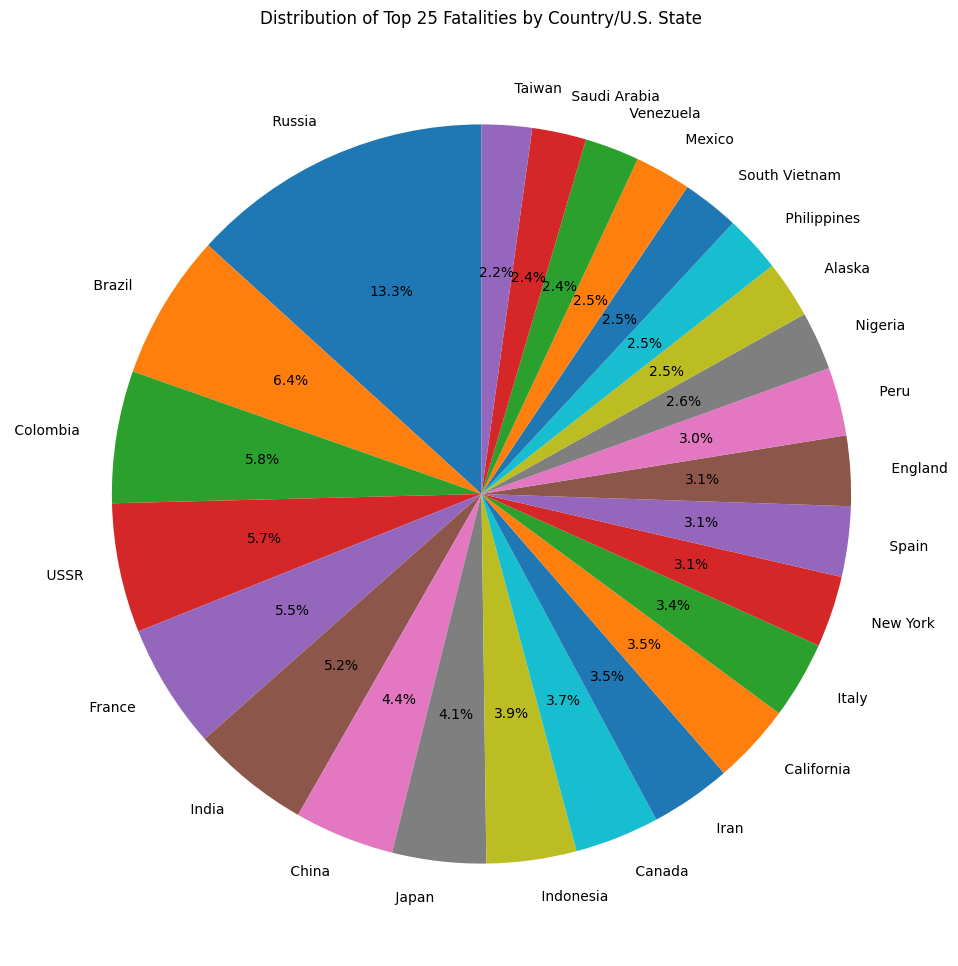

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

fatalities_by_country = (
    fatality_locations
    .groupby("State/Country")["Fatalities"]
    .sum()
    .sort_values(ascending = False)
    .head(25)
)

plt.figure(figsize = (12,12))

plt.pie(
    fatalities_by_country.values,
    labels=fatalities_by_country.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Top 25 Fatalities by Country/U.S. State")

plt.show()